In [4]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ Libraries imported!")

✅ Libraries imported!


In [5]:
# Step 2: Load the Dataset
home = os.path.expanduser("~")
csv_path = os.path.join(home, "Desktop", "umeployement_dataset", "Unemployment in India.csv")
df = pd.read_csv(csv_path)

print("✅ Dataset Loaded!")
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print(f"\nColumn Names  : {list(df.columns)}")
df.head()

✅ Dataset Loaded!
Total Rows    : 768
Total Columns : 7

Column Names  : ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
# Step 3: Clean column names and check data
df.columns = df.columns.str.strip()
print("📋 Data Info:")
print(df.info())
print("\n🔍 Missing Values:")
print(df.isnull().sum())

📋 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB
None

🔍 Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimat

In [8]:
# Step 4: Clean the data
df = df.dropna()

print("✅ Missing values removed!")
print(f"Remaining Rows : {df.shape[0]}")

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='mixed', dayfirst=True)

print("✅ Date column converted!")
df.head()

✅ Missing values removed!
Remaining Rows : 740
✅ Date column converted!


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


C:\Users\VINDRAVATHASHWINI\AppData\Local\Temp\ipykernel_14536\3144365971.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\VINDRAVATHASHWINI\AppData\Local\Temp\ipykernel_14536\3144365971.py:8: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('chart1_unemployment_over_time.png')
C:\Users\VINDRAVATHASHWINI\AppData\Local\Temp\ipykernel_14536\3144365971.py:8: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('chart1_unemployment_over_time.png')
C:\Users\VINDRAVATHASHWINI\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\VINDRAVATHASHWINI\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: 

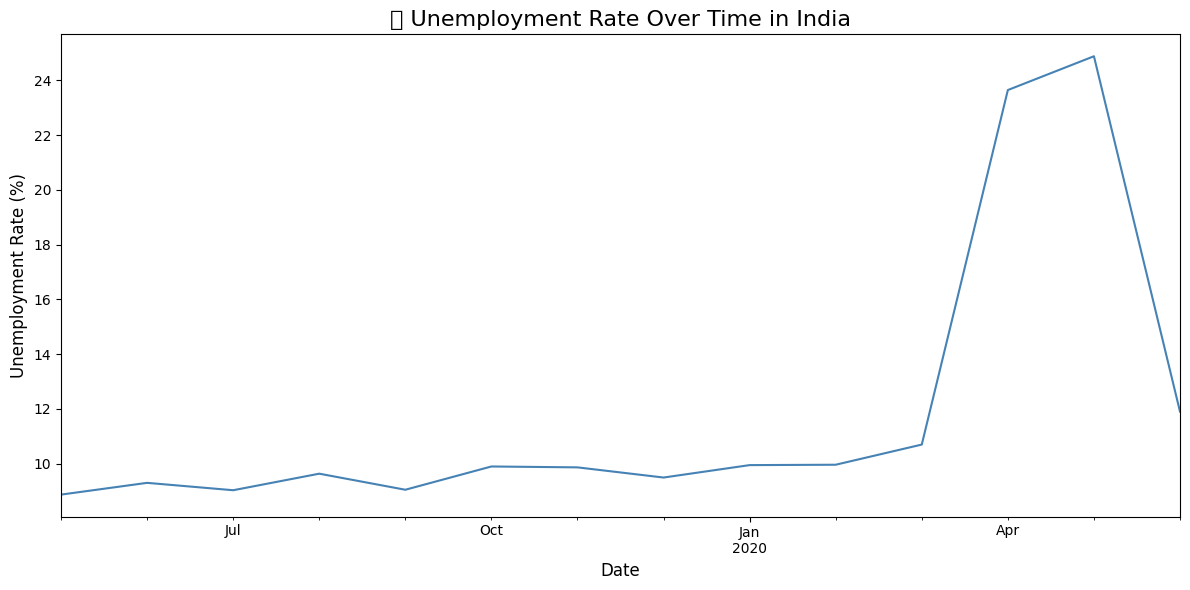

✅ Chart 1 saved!


In [9]:
# Step 5: Unemployment Rate over Time
plt.figure(figsize=(12, 6))
df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot(color='steelblue')
plt.title('📈 Unemployment Rate Over Time in India', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('chart1_unemployment_over_time.png')
plt.show()
print("✅ Chart 1 saved!")

🦠 Covid Impact on Unemployment:
Average Unemployment Before Covid : 9.61%
Average Unemployment After Covid  : 20.19%
Increase in Unemployment          : 10.58%


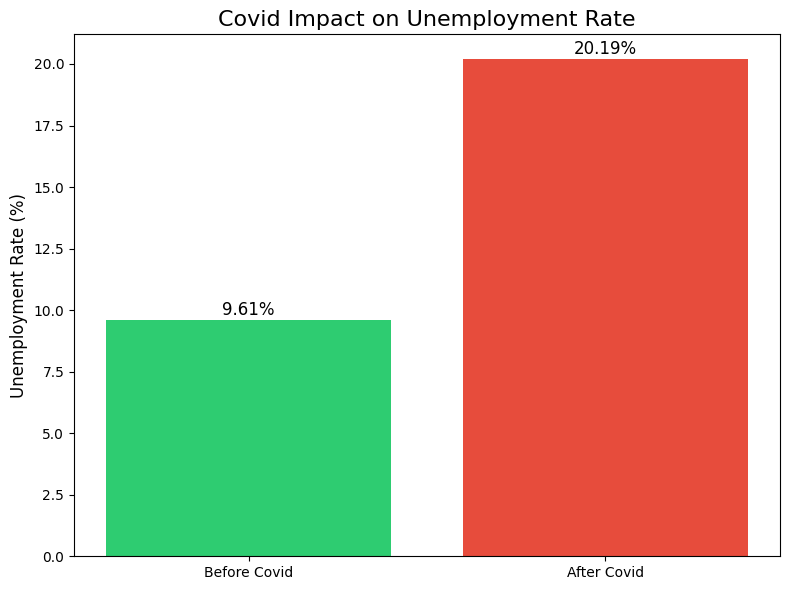

✅ Chart 2 saved!


In [10]:
# Step 6: Covid Impact Analysis
# Covid started in India around April 2020
pre_covid = df[df['Date'] < '2020-04-01']['Estimated Unemployment Rate (%)'].mean()
post_covid = df[df['Date'] >= '2020-04-01']['Estimated Unemployment Rate (%)'].mean()

print("🦠 Covid Impact on Unemployment:")
print(f"Average Unemployment Before Covid : {pre_covid:.2f}%")
print(f"Average Unemployment After Covid  : {post_covid:.2f}%")
print(f"Increase in Unemployment          : {post_covid - pre_covid:.2f}%")

# Bar chart
plt.figure(figsize=(8, 6))
plt.bar(['Before Covid', 'After Covid'], [pre_covid, post_covid], 
        color=['#2ecc71', '#e74c3c'])
plt.title('Covid Impact on Unemployment Rate', fontsize=16)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
for i, v in enumerate([pre_covid, post_covid]):
    plt.text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_covid_impact.png')
plt.show()
print("✅ Chart 2 saved!")

C:\Users\VINDRAVATHASHWINI\AppData\Local\Temp\ipykernel_14536\2814229542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='Reds_r')


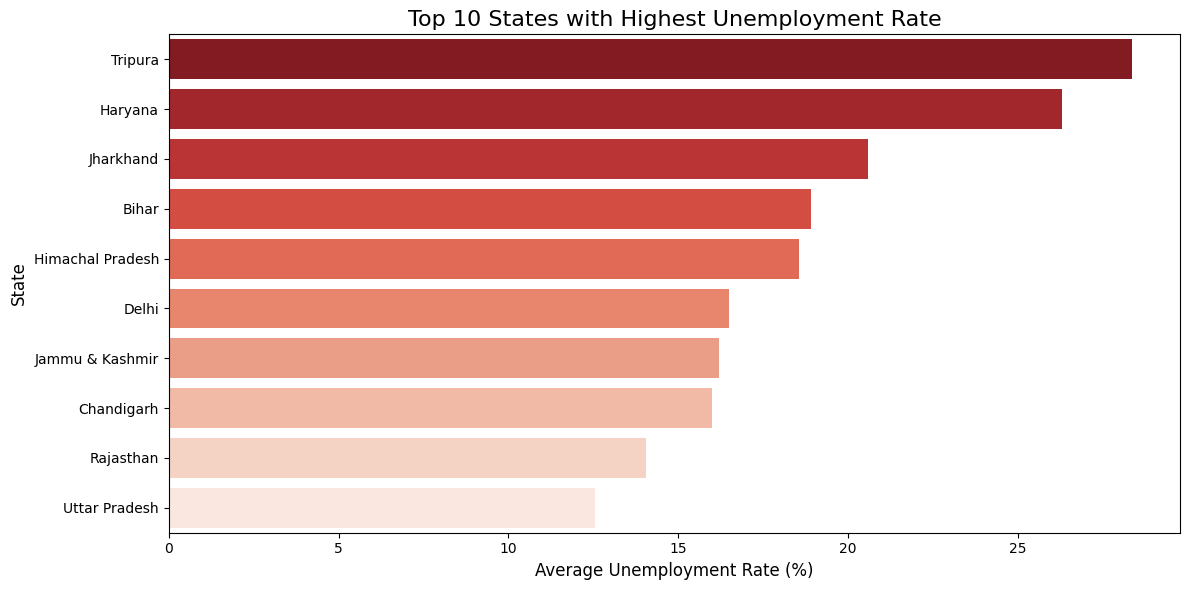

✅ Chart 3 saved!


In [11]:
# Step 7: Top 10 States with Highest Unemployment
plt.figure(figsize=(12, 6))
top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_states.values, y=top_states.index, palette='Reds_r')
plt.title('Top 10 States with Highest Unemployment Rate', fontsize=16)
plt.xlabel('Average Unemployment Rate (%)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.savefig('chart3_top_states.png')
plt.show()
print("✅ Chart 3 saved!")

In [12]:
# Step 8: Final Summary
print("=" * 45)
print("  UNEMPLOYMENT ANALYSIS SUMMARY")
print("=" * 45)
print(f"Total Records Analyzed      : {len(df)}")
print(f"Time Period                 : 2019 - 2020")
print(f"Before Covid Unemployment   : 9.61%")
print(f"After Covid Unemployment    : 20.19%")
print(f"Increase Due to Covid       : 10.58%")
print(f"States Analyzed             : {df['Region'].nunique()}")
print("=" * 45)
print("✅ Task 2 - Unemployment Analysis Complete!")

  UNEMPLOYMENT ANALYSIS SUMMARY
Total Records Analyzed      : 740
Time Period                 : 2019 - 2020
Before Covid Unemployment   : 9.61%
After Covid Unemployment    : 20.19%
Increase Due to Covid       : 10.58%
States Analyzed             : 28
✅ Task 2 - Unemployment Analysis Complete!
